In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

/tmp/ipykernel_32870/3884926229.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
base_dir = '../data/s1/original/'

dfs = []
files = next(os.walk(base_dir))[2]

for file in files:
    dfs.append(pd.read_csv(os.path.join(base_dir, file), encoding='utf-8'))

In [3]:
original_df = pd.concat(dfs, ignore_index=True, sort=True)

                 x            y      cluster          _id
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.641877     0.565991     2.154000   499.500000
std       0.174903     0.209603     0.933357   288.819436
min       0.328162     0.167528     1.000000     0.000000
25%       0.445686     0.307997     1.000000   249.750000
50%       0.624741     0.570947     2.000000   499.500000
75%       0.828927     0.783001     3.000000   749.250000
max       0.914913     0.880495     4.000000   999.000000
cluster
2    316
3    314
1    300
4     70
Name: count, dtype: int64
                 x            y      cluster          _id
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.624774     0.435466     5.280000  1499.500000
std       0.290300     0.251822     0.948947   288.819436
min       0.093828     0.032593     4.000000  1000.000000
25%       0.335568     0.130371     5.000000  1249.750000
50%       0.833661     0.542231     5.000000  1499.500000
75

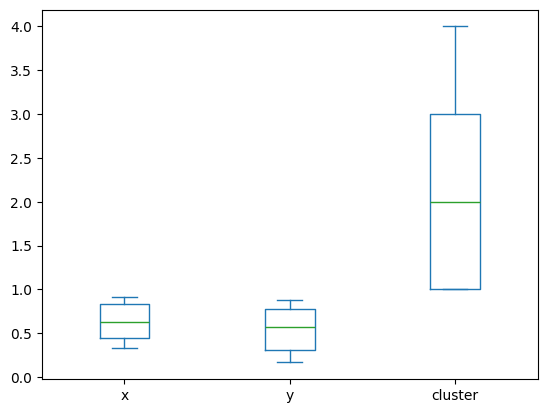

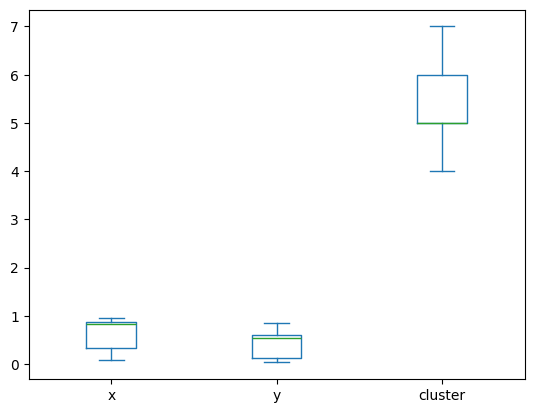

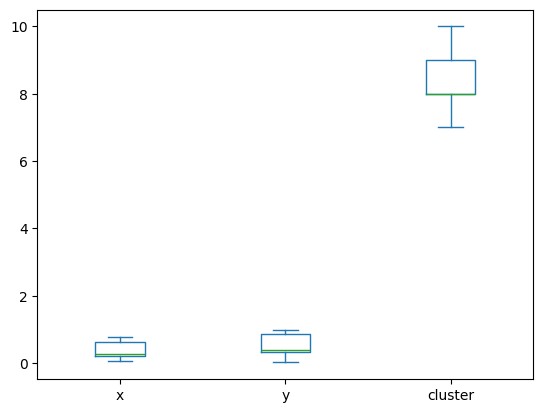

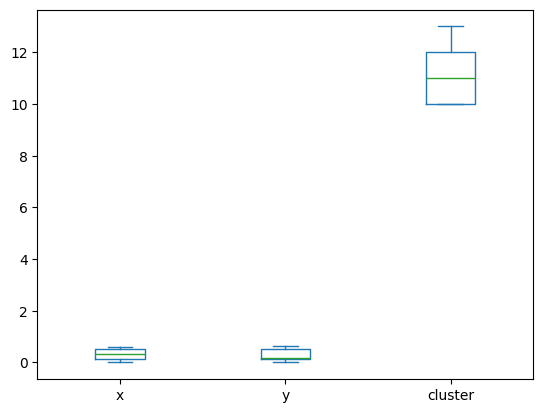

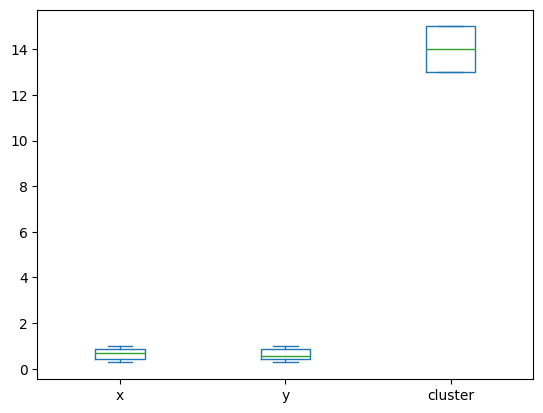

In [4]:
for df in dfs:
    print(df.describe())
    df[df.columns[0:-1]].plot.box()
    print(df['cluster'].value_counts())

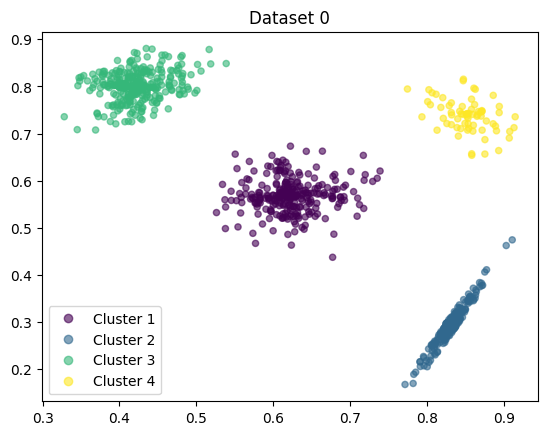

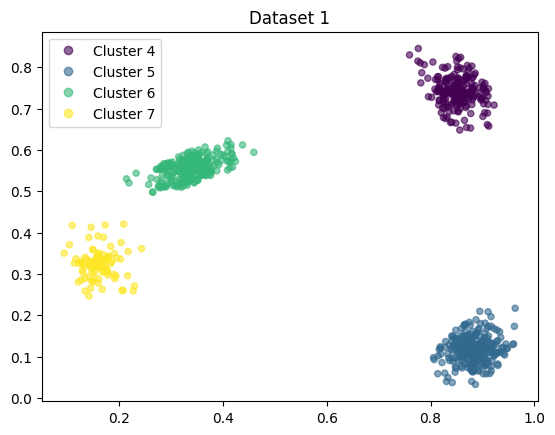

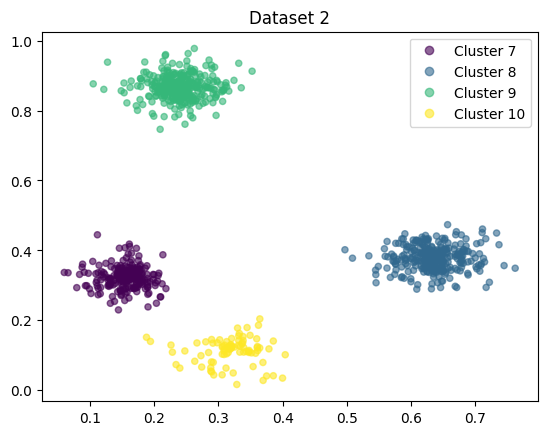

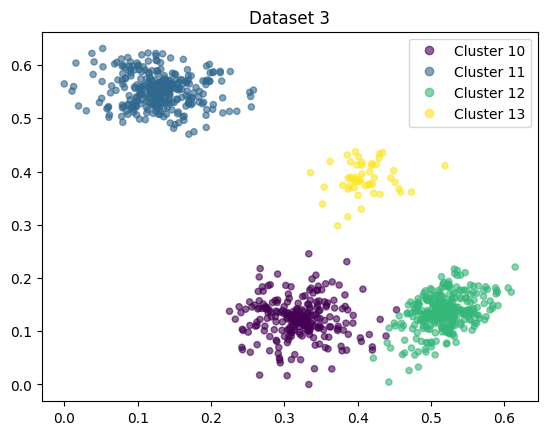

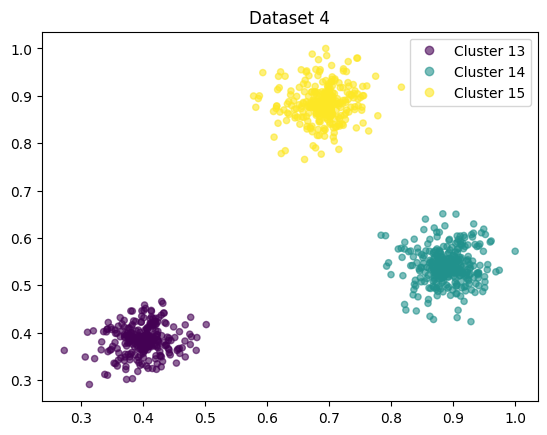

In [5]:
for index, df in enumerate(dfs):
    fig, ax = plt.subplots()
    scatter = plt.scatter(df["x"], df["y"], c=df['cluster'], alpha = 0.6, s=20)
    ax.legend(handles=scatter.legend_elements()[0], labels=map(lambda x: 'Cluster ' + str(x), df['cluster'].unique()))
    ax.set_title(f"Dataset {index}")

In [6]:
base_dir = '../data/s1/continuous/'

dfs = []
files = next(os.walk(base_dir))[2]

for file in files:
    df = pd.read_csv(os.path.join(base_dir, file), encoding='utf-8')
    dfs.append(df)


In [7]:
dfs

[            x         y  cluster   _id
 0    0.683912  0.543504        1     0
 1    0.685701  0.551136        1     1
 2    0.612810  0.570245        1     2
 3    0.635553  0.544047        1     3
 4    0.653693  0.605594        1     4
 ..        ...       ...      ...   ...
 990  0.692459  0.880537       15  4715
 991  0.738891  0.923848       15  4716
 992  0.694608  0.898216       15  4717
 993  0.700533  0.879635       15  4718
 994  0.592999  0.949029       15  4719
 
 [995 rows x 4 columns],
             x         y  cluster   _id
 0    0.709233  0.524571        1    60
 1    0.675758  0.567493        1    61
 2    0.552155  0.557577        1    62
 3    0.613070  0.529820        1    63
 4    0.630188  0.569369        1    64
 ..        ...       ...      ...   ...
 995  0.660287  0.765702       15  4785
 996  0.704558  0.934785       15  4786
 997  0.697501  0.920266       15  4787
 998  0.610206  0.867014       15  4788
 999  0.678168  0.790051       15  4789
 
 [1000 rows

In [5]:
def cluster_wise_f_measure(data):
    sum = 0
    unique_clusters_predicted = sorted(data['cluster'].unique())
    for cluster in unique_clusters_predicted:
    	predicted_cluster = data[data['cluster'] == cluster]
    	true_cluster = cluster_with_max_shared(predicted_cluster, data)
    	sum += f_measure(set(predicted_cluster['_id']), set(true_cluster['_id']))
    
    length = len(unique_clusters_predicted)
    return (sum / length)

def f_measure(pred, true):
    value = (2 * len(pred & true)) / (len(true) + len(pred))
    return value


def cluster_with_max_shared(predicted_cluster, data):
	predicted = set(predicted_cluster['_id'])
	true = data['actual_cluster'].unique()
	max_cluster = 0
	max_session = 0

	for label in true:
		cluster = data[data['actual_cluster'] == label]
		same_cluster = len(predicted & set(cluster['_id']))
		if same_cluster > max_cluster:
			max_cluster = same_cluster
			max_session = label
	return data[data['actual_cluster'] == max_session]

def cluster_wise_jaccard(data):
	sum = 0
	unique_clusters_predicted = sorted(data['cluster'].unique())
	for cluster in unique_clusters_predicted:
		predicted_cluster = data[data['cluster'] == cluster]
		true_cluster = cluster_with_max_shared(predicted_cluster, data)
		sum += jaccard_measure(set(predicted_cluster['_id']), set(true_cluster['_id']))

	length = len(unique_clusters_predicted)
	return (sum / length)


def jaccard_measure(y_true, y_pred):
    return (len(y_pred & y_true)) / (len(y_true) + len(y_pred) - len(y_true & y_pred))

In [16]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import numpy as np
import seaborn as sns

# base_dir = '../results/s1/original/tabular/30/'
# df = pd.read_csv(os.path.join(base_dir, 'final_clustering.csv'), encoding='utf-8')
# df = df[df['is_included']==True]

result_metrics = {}

def eda_clustering(window=30, data_type='original', is_included=False, num_segments = 4):
    print(f"window: {window}")
    base_dir = f'../results/s1/{data_type}/tabular/{window}/'
    df = pd.read_csv(os.path.join(base_dir, 'final_clustering.csv'), encoding='utf-8')
    df = df[df['segment']<=num_segments]
    # print(df.shape)
    if is_included:
        df = df[df['is_included']==True]
    
    df = df.rename(columns={'ids': '_id', 'target': 'actual_cluster'})
    # print(df.head())

    palette = sns.color_palette('hls', n_colors=len(set(df['cluster'])))
    sns.scatterplot(x=df['x'], y=df['y'], hue=df['cluster'], palette=palette)

    plt.show()

    from sklearn.metrics import pairwise_distances,silhouette_score

    def calculate_distances(data):
        return pairwise_distances(data,data)

    print(df['cluster'].unique())
    distances = calculate_distances(df[df.columns[:-6]].to_numpy(copy=True))
    if len(df['cluster'].unique()) > 1:
        SI = silhouette_score(distances, df['cluster'])
    else:
        SI = None
    F1 = cluster_wise_f_measure(df)
    JI = cluster_wise_jaccard(df)
    # print(SI)
    # print(F1)
    # print(JI)

    result_metrics[window] = [SI, F1, JI, df['cluster'].unique()]


window: 32


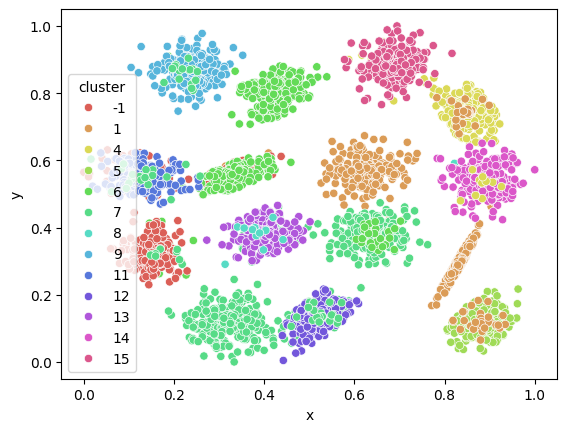

[ 1  6  4  5 -1  7  9 11 12 13  8 14 15]


,SI,F1,JI,cluster_count
30,0.304708,0.829327,0.736933,"[1, 6, 4, 5, -1, 10, 9, 11, 12, 13, 14]"
6,0.217491,0.586592,0.453814,"[10, 13, 4, -1, 5, 6, 7, 16, 18]"
8,0.201858,0.612149,0.543036,"[3, 17, -1, 5, 8, 10, 9, 13, 14, 6, 1, 4, 18]"
12,0.20832,0.727758,0.618716,"[3, 11, 5, -1, 6, 7, 9, 12]"
4,0.054982,0.440275,0.364513,"[12, 7, 3, 35, -1, 9, 10, 15, 14, 19, 18, 17, ..."
24,0.258486,0.816932,0.728211,"[3, 4, 5, -1, 6, 7, 8, 9, 10, 12]"
32,0.266585,0.763401,0.663031,"[1, 6, 4, 5, -1, 7, 9, 11, 12, 13, 8, 14, 15]"


In [25]:
for window in [32]:
    eda_clustering(window=window, data_type='original', is_included=False, num_segments=4)

results_df = pd.DataFrame(result_metrics).T
results_df.columns = ['SI', 'F1', 'JI', 'cluster_count']
results_df